100%|██████████| 170M/170M [38:39<00:00, 73.5kB/s]


Epoch 1/3, Loss: 1.8028
Epoch 2/3, Loss: 1.4329
Epoch 3/3, Loss: 1.2885


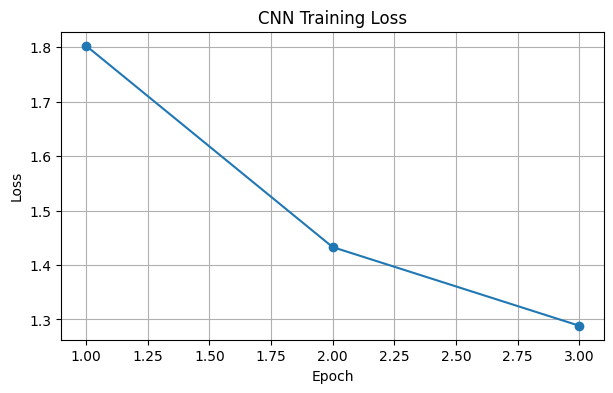

Accuracy on test data: 51.40%


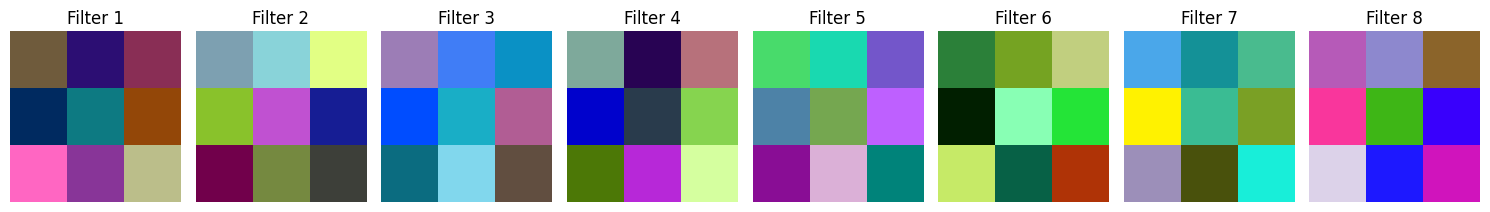

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

trainset = torch.utils.data.Subset(trainset, range(10000))
testset = torch.utils.data.Subset(testset, range(2000))

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=64,
    shuffle=True
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=64,
    shuffle=False
)

classes = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)

        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 32 * 8 * 8)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)

lossfn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

losses = []

for epoch in range(3):

    running_loss = 0.0

    model.train()

    for inputs, labels in trainloader:

        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = lossfn(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(trainloader)
    losses.append(epoch_loss)

    print(f"Epoch {epoch + 1}/3, Loss: {epoch_loss:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(range(1, 4), losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training Loss")
plt.grid(True)
plt.show()

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in testloader:

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Accuracy on test data: {accuracy:.2f}%")

filters = model.conv1.weight.data.clone().cpu()

fig, axs = plt.subplots(1, 8, figsize=(15, 4))

for i in range(8):

    f = filters[i]

    f = (f - f.min()) / (f.max() - f.min())

    axs[i].imshow(f.permute(1, 2, 0))
    axs[i].axis('off')
    axs[i].set_title(f'Filter {i + 1}')

plt.tight_layout()
plt.show()